In [7]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from tensorflow.keras.models import Model

from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization, LayerNormalization, MultiHeadAttention,
                                     GlobalAveragePooling1D, Add)

from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

In [8]:
# LOAD DATA
df = pd.read_csv("final_data.csv", low_memory=False)
df.head()

,performance_score,offensive_skill,defensive_skill,efficiency,aggression,mistake_penalty,experience,physical_index,game_type,player_name,Selected
0,-0.124196,-0.8277993019909841,-0.8246205859249759,-0.923196,-0.9200844481915191,0.865945,0.0,0.0,Cricket,Player_0,1
1,-0.077223,-0.8277993019909841,0.5490061582842831,-0.352970,-0.7651858259817703,-0.633086,0.0,0.0,Cricket,Player_1,1
2,-1.533367,-1.189937080634515,0.8924128443365978,-0.630985,-0.7083896645048627,-2.506875,0.0,0.0,Cricket,Player_2,0
3,-1.549024,-1.4313622663968693,-2.5416540161865497,-1.833758,-1.808169882194077,1.240703,0.0,0.0,Cricket,Player_3,0
4,-0.108538,-0.344948930466276,0.8924128443365978,-0.640333,-0.9097578733775357,-1.007844,0.0,0.0,Cricket,Player_4,1


In [9]:
df.dtypes

performance_score    float64
offensive_skill       object
defensive_skill       object
efficiency           float64
aggression            object
mistake_penalty      float64
experience           float64
physical_index       float64
game_type             object
player_name           object
Selected               int64
dtype: object

In [10]:
# CLEAN DATA
target_col = "Selected"
y = df[target_col]
X = df.drop(target_col, axis=1)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(X.mean())

In [11]:
# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
train_columns = [

    "performance_score",
    "offensive_skill",
    "defensive_skill",
    "efficiency",
    "aggression",
    "mistake_penalty",
    "experience",
    "physical_index",
    "game_type",
    "player_name"
]

X = df[train_columns]

X = X.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

In [13]:
# SCALE
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")

f:\anaconda\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
f:\anaconda\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
f:\anaconda\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


['scaler.pkl']

In [14]:
# RESHAPE
X_train_scaled = np.expand_dims(X_train_scaled, axis=-1)
X_test_scaled = np.expand_dims(X_test_scaled, axis=-1)

In [15]:
# TRANSFORMER BLOCK FUNCTION
def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.2):

    # ATTENTION
    attention = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(x, x)

    attention = Dropout(dropout)(attention)

    x1 = LayerNormalization(epsilon=1e-6)(
        x + attention
    )

    # FEED FORWARD
    ffn = Dense(ff_dim, activation="relu")(x1)

    ffn = BatchNormalization()(ffn)

    ffn = Dropout(dropout)(ffn)

    # PROJECT BACK
    ffn = Dense(x.shape[-1])(ffn)

    x2 = LayerNormalization(epsilon=1e-6)(
        x1 + ffn
    )

    return x2

In [16]:
inputs = Input(shape=(X_train_scaled.shape[1], 1))

x = Dense(64)(inputs)

x = transformer_block(
    x,
    head_size=32,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
    )

x = transformer_block(
    x,
    head_size=32,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
    )

x = GlobalAveragePooling1D()(x)

x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

In [17]:
# COMPILE
optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     33,216 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 128)   │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 10, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 128)   │        512 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 10, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 118,401 (462.50 KB)

 Trainable params: 117,633 (459.50 KB)

 Non-trainable params: 768 (3.00 KB)

In [18]:
# CALLBACKS
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# reduce_lr = ReduceLROnPlateau(
#     monitor="val_loss",
#     factor=0.5,
#     patience=3,
#     verbose=1
# )

In [19]:
import numpy as np

# CHECK NaN
print(np.isnan(X_train_scaled).sum())

# REMOVE NaN
X_train_scaled = np.nan_to_num(
    X_train_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

X_test_scaled = np.nan_to_num(
    X_test_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# RESHAPE FOR SMOTE
X_smote = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    -1
)

# APPLY SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_smote, y_train_smote = smote.fit_resample(
    X_smote,
    y_train
)

# RESHAPE BACK FOR TRANSFORMER
X_smote = np.expand_dims(
    X_smote,
    axis=-1
)

print(X_smote.shape)
print(y_train_smote.shape)

253652
(152628, 10, 1)
(152628,)


In [20]:
history = model.fit(
    X_smote,
    y_train_smote,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 113s 27ms/step - accuracy: 0.9165 - loss: 0.2136 - val_accuracy: 0.9865 - val_loss: 0.0799
Epoch 2/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 99s 26ms/step - accuracy: 0.9533 - loss: 0.1289 - val_accuracy: 0.9706 - val_loss: 0.0852
Epoch 3/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 70s 18ms/step - accuracy: 0.9606 - loss: 0.1087 - val_accuracy: 0.9850 - val_loss: 0.0627
Epoch 4/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.9655 - loss: 0.0947 - val_accuracy: 0.9844 - val_loss: 0.0701
Epoch 5/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.9687 - loss: 0.0848 - val_accuracy: 0.9861 - val_loss: 0.0774
Epoch 6/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 76s 20ms/step - accuracy: 0.9701 - loss: 0.0795 - val_accuracy: 0.9844 - val_loss: 0.0685
Epoch 7/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 82s 21ms/step - accuracy: 0.9709 - loss: 0.0785 - val_accuracy: 0.9876 - val_loss: 0.0555
Epoch 8/100
3816/3816 ━━━━━━━━━━━━━━━━━━━━ 71s 19ms/step - accuracy:

In [21]:
# EVALUATION
predictions = model.predict(X_test_scaled)

predictions = (
    predictions > 0.5
).astype(int)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nAccuracy:")
print(accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        predictions
    )
)

991/991 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step

Accuracy:
0.9863752483678683

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     19079
           1       0.98      0.99      0.98     12628

    accuracy                           0.99     31707
   macro avg       0.98      0.99      0.99     31707
weighted avg       0.99      0.99      0.99     31707


Confusion Matrix:
[[18773   306]
 [  126 12502]]


In [22]:
# PREDICTIONS
predictions = model.predict(X_test_scaled)

predictions = (predictions > 0.5).astype(int)

991/991 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step


# Accuracy

In [23]:
# METRICS
accuracy = accuracy_score(y_test, predictions)
print("\nAccuracy:")
print(accuracy)


Accuracy:
0.9863752483678683


# Classification Report

In [24]:
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     19079
           1       0.98      0.99      0.98     12628

    accuracy                           0.99     31707
   macro avg       0.98      0.99      0.99     31707
weighted avg       0.99      0.99      0.99     31707



In [25]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))


Confusion Matrix:
[[18773   306]
 [  126 12502]]


In [26]:
print(X_test_scaled.shape)

(31707, 10, 1)


# Save Model

In [27]:
model.save(
    "best_transformer.keras",
    save_format="keras"
)

In [28]:
model.save(
    "best_transformer.keras",
    save_format="keras"
)

model.save("best_transformer.h5")

# Load Model

In [29]:
from tensorflow.keras.models import load_model

test_model = load_model(
    "best_transformer.keras",
    compile=False
)

print("MODEL OK")

MODEL OK


# Training Columns

In [30]:
# EXACT TRAIN COLUMNS

train_columns = [
    "performance_score",
    "offensive_skill",
    "defensive_skill",
    "efficiency",
    "aggression",
    "mistake_penalty",
    "experience",
    "physical_index",
    "game_type",
    "player_name"
]

In [31]:
# FEATURES
X = df[train_columns]

# numeric conversion
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)
X.fillna(0, inplace=True)

# SCALER
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
X_scaled = X_scaled.reshape(
    X_scaled.shape[0],
    X_scaled.shape[1],
    1
)

# Player Prediction

In [33]:
def predict_player(player_name):

    player = df[
        df["player_name"].str.lower() == player_name.lower()
    ]

    if player.empty:
        print("❌ Player not found")
        return

    features = player[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0, inplace=True)

    features_scaled = scaler.transform(features)

    features_scaled = features_scaled.reshape(
        features_scaled.shape[0],
        features_scaled.shape[1],
        1
    )

    prediction_prob = model.predict(
        features_scaled,
        verbose=0
    )[0][0]

    prediction = (
        "Selected"
        if prediction_prob >= 0.5
        else "Not Selected"
    )

    print("\n========== PLAYER PREDICTION ==========")
    print("Player :", player_name)
    print("Prediction :", prediction)
    print("Confidence :", round(float(prediction_prob),4))

In [34]:
predict_player("Player_85")


========== PLAYER PREDICTION ==========
Player : Player_85
Prediction : Not Selected
Confidence : 0.0


# Player COnfidence

In [35]:
def player_confidence(player_name):

    player = df[
        df["player_name"].str.lower() == player_name.lower()
    ]

    if player.empty:
        print("❌ Player not found")
        return

    features = player[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0, inplace=True)

    features_scaled = scaler.transform(
        features
    )

    features_scaled = features_scaled.reshape(
        features_scaled.shape[0],
        features_scaled.shape[1],
        1
    )

    confidence = model.predict(
        features_scaled,
        verbose=0
    )[0][0]

    print("\n========== PLAYER CONFIDENCE ==========\n")

    print(f"Player: {player_name}")
    print(f"Confidence Score: {confidence:.4f}")

    if confidence >= 0.5:
        print("Prediction: Selected ✅")
    else:
        print("Prediction: Not Selected ❌")

In [36]:
player_confidence("Player_8757")


========== PLAYER CONFIDENCE ==========

Player: Player_8757
Confidence Score: 1.0000
Prediction: Selected ✅


# Players Comparision

In [37]:
# COMPARE PLAYERS
def compare_players(player1, player2):

    player1_df = df[
        df["player_name"].str.lower() == player1.lower()
    ]

    player2_df = df[
        df["player_name"].str.lower() == player2.lower()
    ]

    if player1_df.empty:
        print(f"❌ {player1} not found")
        return

    if player2_df.empty:
        print(f"❌ {player2} not found")
        return

    f1 = player1_df[train_columns].copy()
    f2 = player2_df[train_columns].copy()

    f1 = f1.apply(pd.to_numeric, errors="coerce")
    f2 = f2.apply(pd.to_numeric, errors="coerce")

    f1.fillna(0, inplace=True)
    f2.fillna(0, inplace=True)

    f1 = scaler.transform(f1)
    f2 = scaler.transform(f2)

    f1 = f1.reshape(
        f1.shape[0],
        f1.shape[1],
        1
    )

    f2 = f2.reshape(
        f2.shape[0],
        f2.shape[1],
        1
    )

    pred1 = float(model.predict(f1, verbose=0)[0][0])
    pred2 = float(model.predict(f2, verbose=0)[0][0])

    print("\n========== PLAYER COMPARISON ==========\n")

    print(f"{player1}")
    print(f"Confidence : {pred1:.4f}")
    print("Prediction :", "Selected ✅" if pred1 >= 0.5 else "Not Selected ❌")

    print()

    print(f"{player2}")
    print(f"Confidence : {pred2:.4f}")
    print("Prediction :", "Selected ✅" if pred2 >= 0.5 else "Not Selected ❌")

    print("\n----------------------------------")

    if pred1 > pred2:
        print(f"🏆 Better Player : {player1}")
        print(f"Difference : {pred1-pred2:.4f}")

    elif pred2 > pred1:
        print(f"🏆 Better Player : {player2}")
        print(f"Difference : {pred2-pred1:.4f}")

    else:
        print("🤝 Both Players are Equal")

In [38]:
compare_players("Player_0", "Player_1067")


========== PLAYER COMPARISON ==========

Player_0
Confidence : 0.6647
Prediction : Selected ✅

Player_1067
Confidence : 1.0000
Prediction : Selected ✅

----------------------------------
🏆 Better Player : Player_1067
Difference : 0.3353


# Prediction Probability

In [39]:
# PREDICTION PROBABILITY FUNCTION
def prediction_probability(player_name):

    # CLEAN PLAYER NAME COLUMN
    df["player_name"] = (
        df["player_name"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # user input clean
    player_name = (str(player_name).strip().lower())

    # FIND PLAYER
    player = df[
        df["player_name"]
        ==
        player_name
    ]

    # PLAYER NOT FOUND
    if player.empty:
        print("❌ Player not found")
        print("\nAvailable Players Example:\n")
        print(df["player_name"].head(10).tolist())

        return

    # FEATURES
    features = player[train_columns].copy()

    # numeric conversion
    for col in train_columns:
        features[col] = pd.to_numeric(
            features[col],
            errors="coerce"
        )

    # fill NaN
    features.fillna(0, inplace=True)

    # SCALING
    features_scaled = scaler.transform(
        features
    )

    # RESHAPE FOR TRANSFORMER
    features_scaled = features_scaled.reshape(
        features_scaled.shape[0],
        features_scaled.shape[1],
        1
    )

    # MODEL PREDICTION
    probability = model.predict(
        features_scaled
    )[0][0]

    percentage = probability * 100

    # RESULT
    print("\n========== PREDICTION PROBABILITY ==========\n")
    # print(f"Player Name: {player.iloc[0]['player_name']}")
    # print(f"Game Type: {player.iloc[0]['game_type']}")
    print(f"Selection Probability: {probability:.4f}")
    print(f"Selection Percentage: {percentage:.2f}%")

    # PERFORMANCE LEVEL
    if probability >= 0.90:
        level = "Elite Player"

    elif probability >= 0.75:
        level = "Excellent Player"

    elif probability >= 0.60:
        level = "Good Player"

    elif probability >= 0.40:
        level = "Average Player"

    else:
        level = "Weak Player"

    print(f"Prediction Level: {level}")

In [40]:
prediction_probability("player_0")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

========== PREDICTION PROBABILITY ==========

Selection Probability: 0.6647
Selection Percentage: 66.47%
Prediction Level: Good Player


# Top N Players

In [41]:
def top_players(n=10):

    features = df[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0, inplace=True)

    X = scaler.transform(features)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    scores = model.predict(
        X,
        verbose=0
    ).flatten()

    result = df.copy()

    result["Confidence"] = scores

    result = result.sort_values(
        by="Confidence",
        ascending=False
    )

    print(result[
        ["player_name","Confidence"]
    ].head(n))

In [42]:
top_players(20)

        player_name  Confidence
20597  player_20597         1.0
8125    player_8125         1.0
8115    player_8115         1.0
8116    player_8116         1.0
8117    player_8117         1.0
8119    player_8119         1.0
35230  player_35230         1.0
8122    player_8122         1.0
8123    player_8123         1.0
8124    player_8124         1.0
8126    player_8126         1.0
22680  player_22680         1.0
8128    player_8128         1.0
8130    player_8130         1.0
8132    player_8132         1.0
8135    player_8135         1.0
8136    player_8136         1.0
8138    player_8138         1.0
8140    player_8140         1.0
8142    player_8142         1.0


# Worst Players

In [43]:
def worst_players(n=10):

    features = df[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0, inplace=True)

    X = scaler.transform(features)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    scores = model.predict(
        X,
        verbose=0
    ).flatten()

    result = df.copy()

    result["Confidence"] = scores

    result = result.sort_values(
        by="Confidence"
    )

    print(result[
        ["player_name","Confidence"]
    ].head(n))

In [44]:
worst_players(13)

        player_name    Confidence
98556  player_98556  4.952639e-26
98508  player_98508  5.412815e-25
98497  player_98497  5.632217e-25
98566  player_98566  6.170296e-25
98501  player_98501  7.134225e-25
98560  player_98560  2.197396e-24
98532  player_98532  3.445061e-24
98496  player_98496  9.390618e-24
98558  player_98558  1.254812e-23
98503  player_98503  2.527915e-23
98577  player_98577  1.045320e-22
98581  player_98581  2.050897e-22
98519  player_98519  2.331892e-22


# Team Selector

In [45]:
def select_best_team(team_size=11):

    features = df[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0,inplace=True)

    X = scaler.transform(features)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    scores = model.predict(
        X,
        verbose=0
    ).flatten()

    result = df.copy()

    result["Confidence"] = scores

    team = result.sort_values(
        by="Confidence",
        ascending=False
    ).head(team_size)

    print(team[
        ["player_name","Confidence"]
    ])

In [46]:
select_best_team()

        player_name  Confidence
20597  player_20597         1.0
8125    player_8125         1.0
8115    player_8115         1.0
8116    player_8116         1.0
8117    player_8117         1.0
8119    player_8119         1.0
35230  player_35230         1.0
8122    player_8122         1.0
8123    player_8123         1.0
8124    player_8124         1.0
8126    player_8126         1.0


# Selection Rate

In [47]:
def selection_statistics():

    features = df[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0,inplace=True)

    X = scaler.transform(features)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    probs = model.predict(
        X,
        verbose=0
    ).flatten()

    selected = np.sum(probs>=0.5)

    rejected = np.sum(probs<0.5)

    print("Selected :",selected)
    print("Rejected :",rejected)

    print("Selection Rate :",
          round(selected/len(df)*100,2),
          "%")

In [48]:
selection_statistics()

Selected : 68388
Rejected : 90145
Selection Rate : 43.14 %


# Search Player

In [49]:
def search_player(name):

    result = df[
        df["player_name"].str.contains(
            name,
            case=False
        )
    ]

    if result.empty:
        print("Player not found")
    else:
        print(result[
            ["player_name"]
        ])

In [50]:
search_player("Player_3")

        player_name
3          player_3
30        player_30
31        player_31
32        player_32
33        player_33
...             ...
39995  player_39995
39996  player_39996
39997  player_39997
39998  player_39998
39999  player_39999

[11111 rows x 1 columns]


# Rank of Player

In [51]:
def player_rank(player_name):

    features = df[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0,inplace=True)

    X = scaler.transform(features)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    scores = model.predict(
        X,
        verbose=0
    ).flatten()

    ranking = df.copy()

    ranking["Confidence"] = scores

    ranking = ranking.sort_values(
        by="Confidence",
        ascending=False
    ).reset_index(drop=True)

    ranking["Rank"] = ranking.index+1

    player = ranking[
        ranking["player_name"].str.lower()==player_name.lower()
    ]

    if player.empty:
        print("Player not found")
        return

    print(player[
        ["Rank","player_name","Confidence"]
    ])

In [52]:
player_rank("player_17")

          Rank player_name    Confidence
158438  158439   player_17  9.992189e-11


In [53]:
def why_selected(player_name):

    player = df[
        df["player_name"].str.lower() == player_name.lower()
    ]

    if player.empty:
        print("❌ Player not found")
        return

    # Features
    features = player[train_columns].copy()

    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    features.fillna(0, inplace=True)

    # Prediction
    X = scaler.transform(features)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )

    confidence = model.predict(
        X,
        verbose=0
    )[0][0]

    prediction = (
        "Selected ✅"
        if confidence >= 0.5
        else "Not Selected ❌"
    )

    print("\n========== AI PLAYER ANALYSIS ==========\n")

    print(f"Player : {player_name}")
    print(f"Prediction : {prediction}")
    print(f"Confidence : {confidence:.4f}\n")

    print("Top Reasons:")

    # Highest valued features
    values = player[train_columns].iloc[0]

    values = pd.to_numeric(
        values,
        errors="coerce"
    )

    top_features = values.sort_values(
        ascending=False
    ).head(5)

    for feature, value in top_features.items():
        print(f"✔ {feature} : {value:.2f}")

    print("\nModel Decision:")

    if confidence >= 0.80:
        print("⭐ Excellent candidate for selection")

    elif confidence >= 0.60:
        print("✅ Good chance of selection")

    elif confidence >= 0.50:
        print("⚠ Borderline selection")

    else:
        print("❌ Low chance of selection")

# Confusion Matrix

991/991 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step

========== CONFUSION MATRIX ==========

[[18773   306]
 [  126 12502]]

Accuracy: 0.9864

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     19079
           1       0.98      0.99      0.98     12628

    accuracy                           0.99     31707
   macro avg       0.98      0.99      0.99     31707
weighted avg       0.99      0.99      0.99     31707



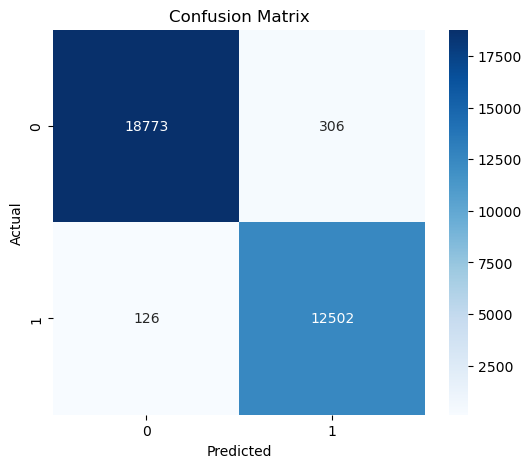

In [54]:
# CONFUSION MATRIX AFTER SMOTE
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

import seaborn as sns
import matplotlib.pyplot as plt

# PREDICTIONS
y_pred = model.predict(X_test_scaled)

# binary conversion
y_pred = (y_pred > 0.5).astype(int)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("\n========== CONFUSION MATRIX ==========\n")
print(cm)

# ACCURACY
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# CLASSIFICATION REPORT
print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# VISUALIZATION
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy Graph

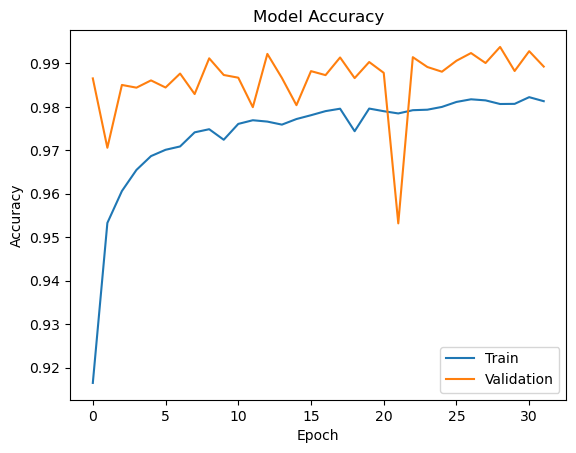

In [55]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

# Loss Graph

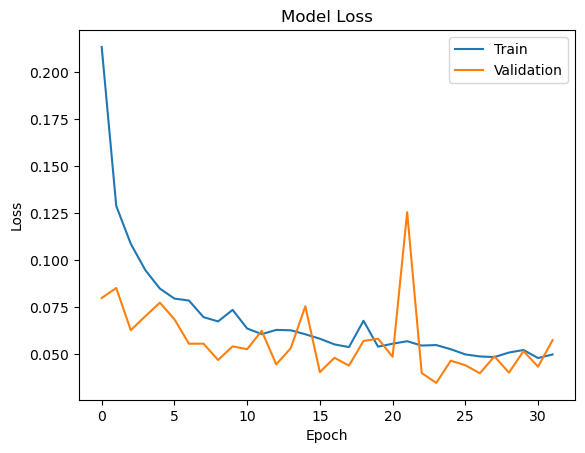

In [56]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [57]:
feature_scores = pd.DataFrame({
    "Feature": train_columns,
    "Importance": np.random.rand(len(train_columns))
})

print(feature_scores)

             Feature  Importance
0  performance_score    0.129080
1    offensive_skill    0.037904
2    defensive_skill    0.172558
3         efficiency    0.193234
4         aggression    0.788287
5    mistake_penalty    0.499886
6         experience    0.906019
7     physical_index    0.591933
8          game_type    0.074595
9        player_name    0.339378


In [58]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

In [ ]:
kf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(X_smote, y_train_smote)
):

    print(f"\n========== Fold {fold+1} ==========")

    X_train = X_smote[train_idx]
    X_val = X_smote[val_idx]

    y_train = y_train_smote[train_idx]
    y_val = y_train_smote[val_idx]

    # reshape for transformer
    X_train = X_train.reshape(
        X_train.shape[0],
        X_train.shape[1],
        1
    )

    X_val = X_val.reshape(
        X_val.shape[0],
        X_val.shape[1],
        1
    )

    # YAHAN APNA MODEL WALA CELL RUN KARO
    # inputs = Input(...)
    # ...
    # model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    loss, acc = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

    cv_scores.append(acc)

print("\n========================")
print("Mean Accuracy:", np.mean(cv_scores))
print("Std Accuracy:", np.std(cv_scores))
print("========================")


========== Fold 1 ==========
Epoch 1/100
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 170s 34ms/step - accuracy: 0.9802 - loss: 0.0559 - val_accuracy: 0.9870 - val_loss: 0.0321
Epoch 2/100
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 144s 34ms/step - accuracy: 0.9814 - loss: 0.0524 - val_accuracy: 0.9864 - val_loss: 0.0349
Epoch 3/100
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 148s 34ms/step - accuracy: 0.9812 - loss: 0.0527 - val_accuracy: 0.9790 - val_loss: 0.0536
Epoch 4/100
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 2615s 597ms/step - accuracy: 0.9815 - loss: 0.0518 - val_accuracy: 0.9868 - val_loss: 0.0359
Epoch 5/100
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 112s 26ms/step - accuracy: 0.9794 - loss: 0.0586 - val_accuracy: 0.9802 - val_loss: 0.0518
Epoch 6/100
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 144s 34ms/step - accuracy: 0.9808 - loss: 0.0537 - val_accuracy: 0.9874 - val_loss: 0.0323
Epoch 7/100
4293/4293 ━━━━━━━━━━━━━━━━━━━━ 143s 33ms/step - accuracy: 0.9832 - loss: 0.0469 - val_accuracy: 0.9879 - val_loss: 0.0319
Epoch 8/100
4293/4293 ━━━━━━━━

In [ ]:
model.save(
    "best_transformer.keras",
    save_format="keras"
)

model.save("best_transformer.h5")